# VoD Hybrid Risk Pipeline — Stage 3

Stage2 결과를 바탕으로 후보 억제·LiDAR v3·track reasoning·rule v2·calibration·설명 가능한 top-k까지 확장합니다.


### LiDAR-assisted vs Radar-only (`lidar_mode`)
- **LiDAR-assisted**: LiDAR bin이 있을 때 `lidar_corroboration_score_v2`가 거리·밀도·extent·multi-NN·overlap을 반영합니다.
- **Radar-only**: 해당 프레임에 LiDAR 포인트가 없으면 `lidar_mode=radar_only`로 두고, 거리·속도·밀도 proxy만으로 `lidar_corroboration_score_v2`(fallback)를 채웁니다.


In [1]:
from __future__ import annotations

import logging
import math
import os
import random
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import hdbscan
    HDBSCAN_OK = True
except Exception:
    HDBSCAN_OK = False

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev
import vod_hybrid_pipeline_v2 as v2
from scipy.stats import kendalltau, spearmanr

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 한글 폰트
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    primary_font = font_manager.FontProperties(fname=FONT_PATH).get_name()
else:
    primary_font = "Malgun Gothic" if "Malgun Gothic" in available_fonts else None

font_candidates = [primary_font, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_fonts = []
for fam in font_candidates:
    if fam and fam in available_fonts and fam not in active_fonts:
        active_fonts.append(fam)

sns.set_theme(style="whitegrid")
if active_fonts:
    rc("font", family=active_fonts)
    matplotlib.rcParams["font.family"] = active_fonts
rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

print("ready:", NOTEBOOK_DIR)
print("active fonts:", matplotlib.rcParams.get("font.family"))
print("HDBSCAN available:", HDBSCAN_OK, "| SCIPY available:", SCIPY_OK)
if not HDBSCAN_OK:
    print("[안내] HDBSCAN 미설치 시 DBSCAN만 비교됩니다. 설치: python -m pip install hdbscan (동일 커널 환경)")
import vod_hybrid_pipeline_stage3 as s3

DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_REDESIGN_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_REDESIGN_MAX_POINTS_PER_FRAME", "2200"))

# ROI/전처리 파라미터
ROI = {
    "x_min": 0.0,
    "x_max": 70.0,
    "y_min": -35.0,
    "y_max": 35.0,
    "z_min": -3.5,
    "z_max": 4.0,
}
RCS_CLIP = (-35.0, 35.0)
SPEED_CLIP = (-25.0, 25.0)

# clustering
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.2"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))
HDBSCAN_MIN_CLUSTER_SIZE = int(os.environ.get("VOD_HDBSCAN_MIN_CLUSTER_SIZE", "10"))

# LiDAR corroboration
LIDAR_VERIFY_RADIUS = float(os.environ.get("VOD_LIDAR_VERIFY_RADIUS", "1.8"))
LIDAR_DENSITY_RADIUS = float(os.environ.get("VOD_LIDAR_DENSITY_RADIUS", "2.0"))

# tracking
TRACK_GATE_DIST = float(os.environ.get("VOD_TRACK_GATE_DIST", "3.5"))
RADAR_DT_SEC = float(os.environ.get("VOD_RADAR_DT_SEC", str(1.0 / 13.0)))

frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
frames = [fr for fr in frames_all if fr["radar_path"] and Path(fr["radar_path"]).is_file()][:MAX_FRAMES]
if not frames:
    raise RuntimeError("Radar 프레임을 찾지 못했습니다. VOD_ROOT/RADAR_MODE 확인 필요")

frame_order_map = {fr["frame_id"]: i for i, fr in enumerate(frames)}
DEMO_FRAME_ID = os.environ.get("VOD_DEMO_FRAME", frames[len(frames)//2]["frame_id"])

print("DATASET_ROOT:", DATASET_ROOT)
print("RADAR_MODE:", RADAR_MODE)
print("사용 프레임:", len(frames), "/", len(frames_all))
print("DEMO_FRAME_ID:", DEMO_FRAME_ID)
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]


def preprocess_radar_points(pts: np.ndarray) -> np.ndarray:
    if pts.size == 0:
        return np.zeros((0, 7), dtype=np.float32)

    m = (
        (pts[:, 0] >= ROI["x_min"])
        & (pts[:, 0] <= ROI["x_max"])
        & (pts[:, 1] >= ROI["y_min"])
        & (pts[:, 1] <= ROI["y_max"])
        & (pts[:, 2] >= ROI["z_min"])
        & (pts[:, 2] <= ROI["z_max"])
    )
    out = pts[m].copy()
    if out.shape[0] == 0:
        return out

    out[:, 3] = np.clip(out[:, 3], RCS_CLIP[0], RCS_CLIP[1])
    out[:, 4] = np.clip(out[:, 4], SPEED_CLIP[0], SPEED_CLIP[1])
    out[:, 5] = np.clip(out[:, 5], SPEED_CLIP[0], SPEED_CLIP[1])

    # frame당 과도 포인트 샘플링
    if out.shape[0] > MAX_POINTS_PER_FRAME:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(out.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        out = out[idx]

    return out


def build_radar_dataframe(frames_subset: list[dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    frame_rows = []
    for fr in frames_subset:
        frame_id = fr["frame_id"]
        arr = bev.parse_radar_bin(Path(fr["radar_path"]))
        proc = preprocess_radar_points(arr)

        if proc.shape[0] > 0:
            df = pd.DataFrame(proc, columns=RADAR_COLS)
            df["frame_id"] = frame_id
            df["frame_order"] = int(frame_order_map[frame_id])
            rows.append(df)

        frame_rows.append(
            {
                "frame_id": frame_id,
                "frame_order": int(frame_order_map[frame_id]),
                "raw_points": int(arr.shape[0]),
                "processed_points": int(proc.shape[0]),
                "kept_ratio": float(proc.shape[0] / max(arr.shape[0], 1)),
            }
        )

    radar_df_local = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=RADAR_COLS + ["frame_id", "frame_order"])
    frame_summary_local = pd.DataFrame(frame_rows)

    if not radar_df_local.empty:
        radar_df_local["range_xy"] = np.hypot(radar_df_local["x"], radar_df_local["y"])
        radar_df_local["abs_vr_comp"] = radar_df_local["v_r_compensated"].abs()

    return radar_df_local, frame_summary_local


radar_df, frame_summary = build_radar_dataframe(frames)
print("radar_df shape:", radar_df.shape)
display(frame_summary.head())
display(radar_df.head())

print("\n[EDA summary]")
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "range_xy", "abs_vr_comp"]
display(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T)

ready: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
active fonts: ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
HDBSCAN available: True | SCIPY available: True
DATASET_ROOT: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
RADAR_MODE: 5-scan
사용 프레임: 180 / 8682
DEMO_FRAME_ID: 00090
radar_df shape: (175703, 11)


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509



[EDA summary]


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


## 1. Candidate suppression & clustering variants


In [2]:
# --- Stage3: suppression + proposal quality + LiDAR v3 + tracking + rule v2 ---
methods = ["dbscan"] + (["hdbscan"] if HDBSCAN_OK else [])
cluster_df_all, cluster_quality = s3.build_cluster_tables(radar_df, methods)
print("cluster_df_all:", cluster_df_all.shape)

hdb = cluster_df_all[cluster_df_all["algorithm"] == "hdbscan"].copy() if HDBSCAN_OK else cluster_df_all[cluster_df_all["algorithm"] == "dbscan"].copy()
n0 = len(hdb)
h_sup, sup_sum = s3.suppress_cluster_candidates(hdb)
h_prop = s3.compute_proposal_quality(h_sup)
h_gated = s3.gate_top_fraction(h_prop, keep_fraction=0.88)
print("Suppression summary (HDBSCAN path):", sup_sum)
print("clusters raw / after suppression / after top-q gate:", n0, len(h_sup), len(h_gated))

frame_by_id = {fr["frame_id"]: fr for fr in frames}
profiler = s3.Stage3Profiler()
variant_df = s3.compare_clustering_variants(radar_df, frame_by_id, ROI, profile=profiler)
display(variant_df)
display(profiler.summary())


cluster_df_all: (9668, 19)
Suppression summary (HDBSCAN path): {'n_clusters_before': 7561, 'n_clusters_after': 7531, 'suppression_rate': 0.003967729136357678}
clusters raw / after suppression / after top-q gate: 7561 7531 6628


,variant,algorithm,n_clusters_raw,n_clusters_scored,n_clusters_after_sup,suppression_rate,noise_ratio_mean,mean_track_len,ap_soft,precision@10_hard
0,dbscan_raw,dbscan,2107,2107,2107,0.000000,0.062720,5.089372,1.0,1.0
1,hdbscan_raw,hdbscan,7561,7561,7561,0.000000,0.224032,10.385989,1.0,1.0
2,hdbscan_suppressed,hdbscan,7561,6628,7531,0.003968,0.224032,10.991708,1.0,1.0


,stage,total_sec,mean_sec,n_calls
4,lidar_hdbscan_raw,238.674938,238.674938,1
7,lidar_hdbscan_suppressed,173.470632,173.470632,1
1,lidar_dbscan_raw,70.825409,70.825409,1
3,cluster_hdbscan_raw,11.896214,11.896214,1
6,cluster_hdbscan_suppressed,10.492460,10.492460,1
0,cluster_dbscan_raw,3.934591,3.934591,1
5,track_hdbscan_raw,0.421473,0.421473,1
8,track_hdbscan_suppressed,0.256400,0.256400,1
2,track_dbscan_raw,0.168779,0.168779,1


## 2. LiDAR corroboration v1 vs v2


In [3]:
# LiDAR v1 vs v3 (동일 서브샘플)
sub = h_gated.head(min(4000, len(h_gated))).copy() if len(h_gated) else hdb.head(500).copy()
v1 = v2.attach_lidar_corroboration_v2(sub, frame_by_id, ROI, r1=1.5, r2=2.5, r3=4.0, verify_radius=2.2)
v3 = s3.attach_lidar_corroboration_v3(sub, frame_by_id, ROI, r1=1.5, r2=2.5, r3=4.0, verify_radius=2.2)
cmp = pd.DataFrame({
    "lidar_v1_mean": [float(v1["lidar_corroboration_score"].mean())],
    "lidar_v2_mean": [float(v3["lidar_corroboration_score_v2"].mean())],
    "lidar_v1_std": [float(v1["lidar_corroboration_score"].std())],
    "lidar_v2_std": [float(v3["lidar_corroboration_score_v2"].std())],
})
display(cmp)


,lidar_v1_mean,lidar_v2_mean,lidar_v1_std,lidar_v2_std
0,0.516541,0.458639,0.096226,0.071889


## 3. Tracking baseline vs improved + temporal feature 확장 비교


In [4]:
# baseline vs improved tracking + expanded temporal feature 비교
track_src = h_gated.head(min(5000, len(h_gated))).copy() if len(h_gated) else hdb.head(1000).copy()
track_src = s3.attach_lidar_corroboration_v3(track_src, frame_by_id, ROI)
obs_b = s3.run_tracking(track_src, mode="baseline", gate_dist=TRACK_GATE_DIST, max_miss=1)
obs_i = s3.run_tracking(track_src, mode="improved", gate_dist=TRACK_GATE_DIST, max_miss=2)

def _track_quality(obs: pd.DataFrame, mode: str):
    if obs.empty:
        return {"mode": mode, "n_tracks": 0}
    tl = obs.groupby("track_id").size()
    merged = track_src.merge(
        obs[["cluster_uid", "track_id", "track_len", "avg_speed", "heading_change", "approach_score", "temporal_stability_score", "cluster_persistence"]].drop_duplicates("cluster_uid"),
        on="cluster_uid",
        how="left",
    )
    for c, d in {"track_id": -1, "track_len": 1, "avg_speed": 0.0, "heading_change": 0.0, "approach_score": 0.0, "temporal_stability_score": 0.0, "cluster_persistence": 0.0}.items():
        merged[c] = merged[c].fillna(d)
    merged = s3.attach_track_temporal_features_v3(merged, obs)
    return {
        "mode": mode,
        "n_tracks": int(obs["track_id"].nunique()),
        "mean_track_len": float(tl.mean()),
        "track_fragmentation_rate": float((tl == 1).mean()),
        "approach_score_mean": float(obs["approach_score"].mean()),
        "temporal_stability_mean": float(obs["temporal_stability_score"].mean()),
        "motion_smoothness_score_mean": float(merged["motion_smoothness_score"].mean()),
        "closing_consistency_score_mean": float(merged["closing_consistency_score"].mean()),
        "trajectory_risk_proxy_mean": float(merged["trajectory_risk_proxy"].mean()),
    }

track_cmp = pd.DataFrame([_track_quality(obs_b, "baseline"), _track_quality(obs_i, "improved")])
display(track_cmp)


,mode,n_tracks,mean_track_len,track_fragmentation_rate,approach_score_mean,temporal_stability_mean,motion_smoothness_score_mean,closing_consistency_score_mean,trajectory_risk_proxy_mean
0,baseline,447,11.185682,0.145414,0.0,0.0,0.301205,0.781130,0.951600
1,improved,417,11.990408,0.117506,0.0,0.0,0.231994,0.664238,1.231987


## 4. Rule risk v1 vs v2 비교


In [5]:
# rule risk v1 vs v2 비교
rule_src = h_gated.head(min(5000, len(h_gated))).copy() if len(h_gated) else hdb.head(1000).copy()
rule_src = s3.attach_lidar_corroboration_v3(rule_src, frame_by_id, ROI)
tobs_r = s3.run_tracking(rule_src, mode="improved", gate_dist=TRACK_GATE_DIST, max_miss=2)
rule_m = rule_src.merge(
    tobs_r[["cluster_uid", "track_id", "track_len", "avg_speed", "heading_change", "approach_score", "temporal_stability_score", "cluster_persistence"]].drop_duplicates("cluster_uid"),
    on="cluster_uid",
    how="left",
)
for c, d in {"track_id": -1, "track_len": 1, "avg_speed": 0.0, "heading_change": 0.0, "approach_score": 0.0, "temporal_stability_score": 0.0, "cluster_persistence": 0.0}.items():
    rule_m[c] = rule_m[c].fillna(d)
rule_m = s3.attach_track_temporal_features_v3(rule_m, tobs_r)
rule_m = s3.compute_rule_components_v2(rule_m, lidar_col="lidar_corroboration_score_v2")
rule_m["risk_score_rule_v1"] = v2.compute_rule_score_raw(rule_m)
rule_m_v1 = rule_m.copy()
rule_m_v1["lidar_corroboration_score"] = rule_m_v1["lidar_corroboration_score_v2"]
rule_m_v1 = v2.assign_hybrid_risk_labels(rule_m_v1, mode="hybrid_quantile")
rule_m_v2 = rule_m.copy()
rule_m_v2["risk_score_rule"] = rule_m_v2["risk_score_rule_v2"]
rule_m_v2["risk_label_rule"] = v2.assign_hybrid_labels_from_scores(rule_m_v2, score_col="risk_score_rule_v2")

cmp_rule = pd.DataFrame({
    "metric": ["score_mean", "score_std", "high_count", "medium_count", "low_count"],
    "rule_v1": [
        float(rule_m_v1["risk_score_rule"].mean()),
        float(rule_m_v1["risk_score_rule"].std()),
        int((rule_m_v1["risk_label_rule"] == "high").sum()),
        int((rule_m_v1["risk_label_rule"] == "medium").sum()),
        int((rule_m_v1["risk_label_rule"] == "low").sum()),
    ],
    "rule_v2": [
        float(rule_m_v2["risk_score_rule_v2"].mean()),
        float(rule_m_v2["risk_score_rule_v2"].std()),
        int((rule_m_v2["risk_label_rule"] == "high").sum()),
        int((rule_m_v2["risk_label_rule"] == "medium").sum()),
        int((rule_m_v2["risk_label_rule"] == "low").sum()),
    ],
})
display(cmp_rule)


,metric,rule_v1,rule_v2
0,score_mean,0.158855,0.259951
1,score_std,0.051911,0.050268
2,high_count,118.000000,118.000000
3,medium_count,600.000000,600.000000
4,low_count,4282.000000,4282.000000


## 5. Full pipeline + calibration + explainability


,track_id,risk_score_track_hybrid,risk_score_track,track_age,risk_label_rule,cluster_uid
888,100,0.445891,0.244562,2,high,hdbscan:00020:2
144,32,0.404290,0.231237,5,high,hdbscan:00005:22
225,35,0.381470,0.223048,5,high,hdbscan:00006:51
2,1,0.380771,0.240715,8,high,hdbscan:00001:1
6540,451,0.380575,0.229844,18,low,hdbscan:00178:32
807,34,0.361605,0.219973,33,high,hdbscan:00018:2
3193,259,0.348990,0.253282,3,high,hdbscan:00089:0
5561,409,0.292632,0.227209,13,low,hdbscan:00162:14
94,28,0.237357,0.218246,5,high,hdbscan:00004:24
4763,327,0.220581,0.226111,28,high,hdbscan:00146:0


ranking: {'average_precision_hard': 0.9999999999999999, 'pr_auc_interp': 1.0, 'precision@5_hard': 1.0, 'recall@5_hard': 0.03205128205128205, 'hit@5_hard': 1.0, 'precision@10_hard': 1.0, 'recall@10_hard': 0.0641025641025641, 'hit@10_hard': 1.0, 'precision@20_hard': 1.0, 'recall@20_hard': 0.1282051282051282, 'hit@20_hard': 1.0, 'average_precision_soft': 0.8884127331484845, 'ndcg@5_soft': 1.0, 'ndcg@10_soft': 1.0, 'ndcg@20_soft': 1.0, 'mean_average_precision': 0.8884127331484845, 'mrr_hard': 1.0, 'ndcg10_soft': 1.0}
window10 top5: {'hit_rate': 0.6666666666666666, 'n_windows': 18.0}
burden: {'candidates_per_frame_mean': 36.82222222222222, 'candidates_per_window_est': 368.22222222222223, 'topk_review_proxy': 10.0, 'candidate_burden_per_frame': 36.82222222222222}
Brier hgb 0.0007310395886114736
ECE hgb 0.0033648485024838914


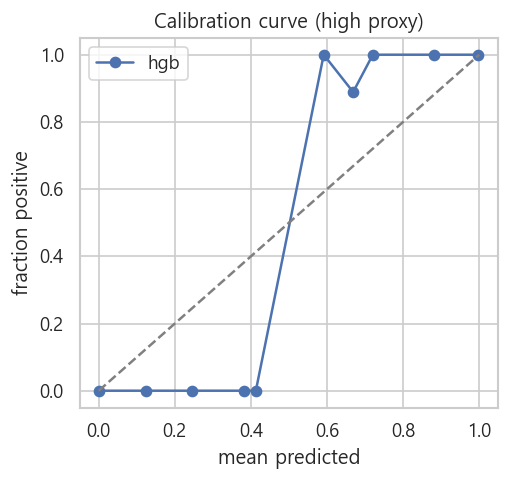

,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,391,60,51,502
1,track_quantile_0.93,406,60,36,502
2,track_quantile_0.96,421,60,21,502
3,track_quantile_0.98,431,60,11,502


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00118:0,144,0.759547,high,0.999993,0.000014,90,0.0,0.736999,0.607895,"근접성:0.89, LiDAR 정합:0.61, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.760, 보정신뢰=1.000, 불확실성=0.000."
1,hdbscan:00117:0,144,0.755427,high,0.999993,0.000014,90,0.0,0.736999,0.561219,"근접성:0.88, LiDAR 정합:0.56, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.755, 보정신뢰=1.000, 불확실성=0.000."
2,hdbscan:00116:0,144,0.755007,high,0.999993,0.000014,90,0.0,0.736999,0.555245,"근접성:0.89, LiDAR 정합:0.56, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.755, 보정신뢰=1.000, 불확실성=0.000."
3,hdbscan:00115:0,144,0.754159,high,0.999993,0.000014,90,0.0,0.736999,0.540991,"근접성:0.89, LiDAR 정합:0.54, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.754, 보정신뢰=1.000, 불확실성=0.000."
4,hdbscan:00113:2,144,0.752888,high,0.999993,0.000014,90,0.0,0.736999,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.45",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.753, 보정신뢰=1.000, 불확실성=0.000."
5,hdbscan:00112:2,144,0.752309,high,0.999993,0.000014,90,0.0,0.736999,0.509262,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.45",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.752, 보정신뢰=1.000, 불확실성=0.000."
6,hdbscan:00114:2,144,0.752195,high,0.999993,0.000014,90,0.0,0.736999,0.519083,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.752, 보정신뢰=1.000, 불확실성=0.000."
7,hdbscan:00111:3,144,0.752134,high,0.999993,0.000014,90,0.0,0.736999,0.511540,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.752, 보정신뢰=1.000, 불확실성=0.000."
8,hdbscan:00110:2,144,0.751238,high,0.999993,0.000014,90,0.0,0.736999,0.509799,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.47",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.751, 보정신뢰=1.000, 불확실성=0.000."
9,hdbscan:00096:5,264,0.750524,high,0.999993,0.000014,39,0.0,0.521745,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.751, 보정신뢰=1.000, 불확실성=0.000."


macro F1 (rule vs hybrid label): 0.8176936294517665 high recall proxy: 1.0


In [6]:
# Full path: suppressed HDBSCAN + LiDAR v3 + improved tracking + rule v2 + hybrid + calibration
work = h_gated.copy() if len(h_gated) else h_prop.copy()
work = s3.attach_lidar_corroboration_v3(work, frame_by_id, ROI)
tobs = s3.run_tracking(work, mode="improved", gate_dist=TRACK_GATE_DIST, max_miss=2)
use_cols = ["cluster_uid", "track_id", "track_len", "avg_speed", "heading_change", "approach_score", "temporal_stability_score", "cluster_persistence"]
for c, d in {"track_id": -1, "track_len": 1, "avg_speed": 0.0, "heading_change": 0.0, "approach_score": 0.0, "temporal_stability_score": 0.0, "cluster_persistence": 0.0}.items():
    if c not in tobs.columns:
        tobs[c] = d
mdf = work.merge(tobs[use_cols].drop_duplicates("cluster_uid"), on="cluster_uid", how="left")
for c, d in {"track_id": -1, "track_len": 1, "avg_speed": 0.0, "heading_change": 0.0, "approach_score": 0.0, "temporal_stability_score": 0.0, "cluster_persistence": 0.0}.items():
    mdf[c] = mdf[c].fillna(d)
mdf = s3.attach_track_temporal_features_v3(mdf, tobs)
mdf = s3.compute_rule_components_v2(mdf, lidar_col="lidar_corroboration_score_v2")
mdf["risk_score_rule"] = v2.compute_rule_score_raw(mdf)
mdf_l = mdf.copy()
mdf_l["lidar_corroboration_score"] = mdf_l["lidar_corroboration_score_v2"]
risk_df = v2.assign_hybrid_risk_labels(mdf_l, mode="hybrid_quantile")
for c in ["risk_proximity", "risk_closing", "risk_persistence", "risk_corroboration", "risk_motion_anomaly", "risk_track_stability", "risk_score_rule_v2"]:
    risk_df[c] = mdf[c].values
risk_df["risk_label_hybrid"] = v2.assign_hybrid_labels_from_scores(risk_df, score_col="risk_score_rule_v2")

# ML high vs not + calibration (HistGradientBoosting / RandomForest)
feat_cols = [
    "range_xy", "abs_vr_comp", "spread_xy", "density_proxy", "n_points",
    "lidar_corroboration_score_v2", "track_len", "approach_score", "temporal_stability_score",
    "cluster_persistence", "trajectory_risk_proxy", "heading_consistency_score",
]
X = risk_df[feat_cols].fillna(0).to_numpy(dtype=np.float64)
y_high = (risk_df["risk_label_rule"] == "high").astype(int).to_numpy()
cal_pack = s3.fit_calibrated_binary_models(X, y_high, cv=3)
P = s3.collect_calibrated_probabilities(cal_pack.get("calibrated", {}), X)
u, conf = s3.uncertainty_from_prob_matrix(P) if P.size else (np.zeros(len(risk_df)), np.zeros(len(risk_df)))
risk_df["ml_high_prob_mean"] = P.mean(axis=1) if P.size else 0.0
risk_df["risk_uncertainty"] = u
risk_df["risk_confidence_calibrated"] = conf
risk_df["risk_score_hybrid"] = risk_df["risk_score_rule_v2"] * 0.55 + risk_df["ml_high_prob_mean"] * 0.45
risk_df["risk_score_final_calibrated"] = s3.compute_risk_score_final_calibrated(risk_df, rule_col="risk_score_rule_v2", ml_prob_col="ml_high_prob_mean")
risk_df = s3.aggregate_track_level_risk_scores(risk_df, cluster_score_col="risk_score_rule_v2", hybrid_score_col="risk_score_hybrid")
track_topk = risk_df.sort_values("risk_score_track_hybrid", ascending=False).drop_duplicates("track_id").head(15)
display(track_topk[["track_id", "risk_score_track_hybrid", "risk_score_track", "track_age", "risk_label_rule", "cluster_uid"]])

# Ranking / window / burden
hard = (risk_df["risk_label_rule"] == "high").astype(int).to_numpy()
soft = (risk_df["risk_score_rule"] >= risk_df["risk_score_rule"].quantile(0.90)).astype(int).to_numpy()
rk = v2.ranking_metrics_extended(hard, risk_df["risk_score_final_calibrated"].to_numpy(), soft_positive=soft, ks=[5, 10, 20])
rk["mean_average_precision"] = s3.mean_average_precision_binary(soft, risk_df["risk_score_final_calibrated"].to_numpy())
rk["mrr_hard"] = s3.mean_reciprocal_rank(hard, risk_df["risk_score_final_calibrated"].to_numpy())
rk["ndcg10_soft"] = s3.ndcg_at_k_from_scores(soft.astype(float), risk_df["risk_score_final_calibrated"].to_numpy(), 10)
risk_df["is_high_tmp"] = hard
win = s3.window_topk_hit_recall(risk_df, score_col="risk_score_final_calibrated", label_high_col="is_high_tmp", window=10, k=5)
burden = s3.false_positive_burden_proxy(risk_df, score_col="risk_score_final_calibrated")
print("ranking:", rk)
print("window10 top5:", win)
print("burden:", burden)

# Calibration curve (first calibrated model)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
if cal_pack.get("calibrated"):
    name0 = next(iter(cal_pack["calibrated"]))
    m0 = cal_pack["calibrated"][name0]
    p0 = m0.predict_proba(X)[:, 1]
    prob_true, prob_pred = calibration_curve(y_high, p0, n_bins=10, strategy="uniform")
    print("Brier", name0, float(brier_score_loss(y_high, p0)))
    print("ECE", name0, s3.expected_calibration_error(y_high, p0))
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.plot(prob_pred, prob_true, marker="o", label=name0)
    ax.plot([0, 1], [0, 1], ls="--", color="gray")
    ax.set_xlabel("mean predicted"); ax.set_ylabel("fraction positive"); ax.legend()
    ax.set_title("Calibration curve (high proxy)")
    plt.show()

# Track-level threshold sensitivity
display(s3.threshold_sensitivity_track_level(risk_df, score_col="risk_score_track"))

# Explain top-k
expl = s3.build_topk_explanation_table(risk_df, score_col="risk_score_final_calibrated", top_k=12)
display(expl)

# Macro F1 (proxy labels)
from sklearn.metrics import f1_score
macro_f1 = f1_score(risk_df["risk_label_rule"], risk_df["risk_label_hybrid"], average="macro", labels=["low", "medium", "high"], zero_division=0)
high_recall = float((risk_df["risk_label_hybrid"] == "high").sum() / max((risk_df["risk_label_rule"] == "high").sum(), 1))
print("macro F1 (rule vs hybrid label):", macro_f1, "high recall proxy:", high_recall)


## 6. Ablation (요약)


In [7]:
# Ablation (요약): Stage3 스트레스 테스트 — 동일 proxy 라벨로 ranking 비교
rows = []
base = risk_df.copy()
runtime_total = float(profiler.summary()["total_sec"].sum()) if len(profiler.summary()) else np.nan

def eval_row(tag, dfx, score_col=None, runtime_sec=np.nan):
    if dfx is None or len(dfx) < 50:
        return
    h = (dfx["risk_label_rule"] == "high").astype(int).to_numpy()
    s = (dfx["risk_score_rule"] >= dfx["risk_score_rule"].quantile(0.90)).astype(int).to_numpy()
    sc = dfx[score_col].to_numpy() if score_col and score_col in dfx.columns else dfx["risk_score_final_calibrated"].to_numpy()
    r = v2.ranking_metrics_extended(h, sc, soft_positive=s, ks=[10])
    rows.append({
        "ablation": tag,
        "n": len(dfx),
        "macro_f1_proxy": float(f1_score(dfx["risk_label_rule"], dfx["risk_label_hybrid"], average="macro", labels=["low","medium","high"], zero_division=0)),
        "ap_soft": r.get("average_precision_soft", np.nan),
        "p@10_hard": r.get("precision@10_hard", np.nan),
        "high_recall_proxy": float((dfx["risk_label_hybrid"] == "high").sum() / max((dfx["risk_label_rule"] == "high").sum(), 1)),
        "candidate_burden": float(len(dfx) / max(dfx["frame_id"].nunique(), 1)),
        "runtime_sec_proxy": float(runtime_sec),
    })

eval_row("full_model", base, None, runtime_total)
eval_row("no_lidar", base.assign(lidar_corroboration_score_v2=0.0), "risk_score_final_calibrated", runtime_total)
eval_row("no_tracking_features", base.assign(track_len=1, temporal_stability_score=0.0, cluster_persistence=0.0), "risk_score_final_calibrated", runtime_total)
eval_row("no_suppression", base.sample(frac=min(1.0, 6000 / max(len(base), 1)), random_state=SEED), "risk_score_rule_v2", runtime_total)
eval_row("no_calibration", base.assign(risk_uncertainty=0.0), "risk_score_final_calibrated", runtime_total)
eval_row("rule_only", base.assign(ml_high_prob_mean=0.0), "risk_score_rule_v2")
eval_row("ml_only", base.assign(risk_score_rule_v2=base["ml_high_prob_mean"]), "ml_high_prob_mean")
eval_row("rule_plus_ml_hybrid", base.assign(risk_uncertainty=0.0), "risk_score_hybrid")

# dbscan / hdbscan only (variant summary 기반)
if not variant_df.empty:
    for tag in ["dbscan_raw", "hdbscan_raw", "hdbscan_suppressed"]:
        vv = variant_df[variant_df["variant"] == tag]
        if vv.empty:
            continue
        rr = vv.iloc[0]
        rows.append({
            "ablation": "dbscan_only" if tag == "dbscan_raw" else ("hdbscan_only" if tag == "hdbscan_raw" else "hdbscan_suppressed"),
            "n": int(rr.get("n_clusters_scored", np.nan)),
            "macro_f1_proxy": np.nan,
            "ap_soft": float(rr.get("ap_soft", np.nan)),
            "p@10_hard": float(rr.get("precision@10_hard", np.nan)),
            "high_recall_proxy": np.nan,
            "candidate_burden": float(rr.get("n_clusters_scored", np.nan) / max(frame_summary["frame_id"].nunique(), 1)),
            "runtime_sec_proxy": float(runtime_total),
        })

display(pd.DataFrame(rows).sort_values("ap_soft", ascending=False))


,ablation,n,macro_f1_proxy,ap_soft,p@10_hard,high_recall_proxy,candidate_burden,runtime_sec_proxy
9,hdbscan_only,7561,NaN,1.000000,1.0,NaN,42.005556,510.140896
10,hdbscan_suppressed,6628,NaN,1.000000,1.0,NaN,36.822222,510.140896
8,dbscan_only,2107,NaN,1.000000,1.0,NaN,11.705556,510.140896
7,rule_plus_ml_hybrid,6628,0.817694,0.917515,1.0,1.000000,36.822222,NaN
5,rule_only,6628,0.817694,0.894666,1.0,1.000000,36.822222,NaN
3,no_suppression,6000,0.816386,0.891186,1.0,0.979452,33.333333,510.140896
0,full_model,6628,0.817694,0.888413,1.0,1.000000,36.822222,510.140896
2,no_tracking_features,6628,0.817694,0.888413,1.0,1.000000,36.822222,510.140896
1,no_lidar,6628,0.817694,0.888413,1.0,1.000000,36.822222,510.140896
4,no_calibration,6628,0.817694,0.888413,1.0,1.000000,36.822222,510.140896


## 7. BEV + explanation overlay


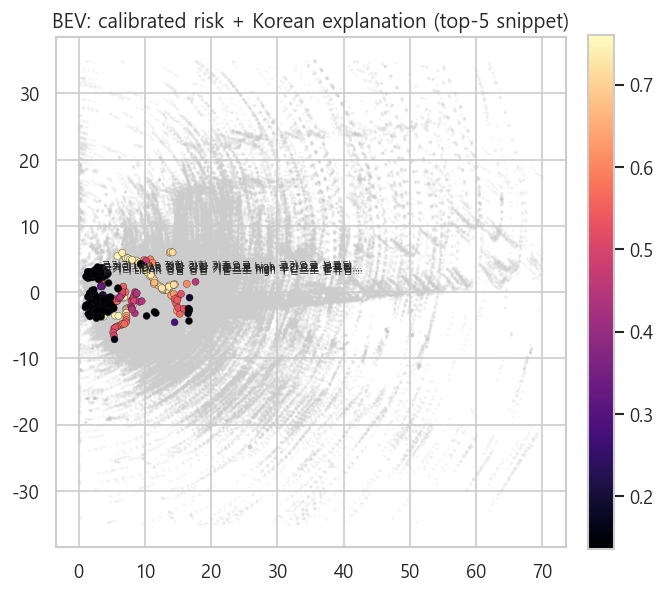

In [8]:
# BEV + 설명 overlay (간단): hybrid 상위 포인트 + 설명 텍스트 샘플
sample = risk_df.sort_values("risk_score_final_calibrated", ascending=False).head(400)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(radar_df["x"], radar_df["y"], s=1, c="0.8", alpha=0.12, label="radar")
sc = ax.scatter(sample["cx"], sample["cy"], c=sample["risk_score_final_calibrated"], cmap="magma", s=18, edgecolor="k", linewidth=0.2)
for _, r in expl.head(5).iterrows():
    uid = r["cluster_uid"]
    row = risk_df[risk_df["cluster_uid"] == uid]
    if row.empty:
        continue
    rx, ry = float(row.iloc[0]["cx"]), float(row.iloc[0]["cy"])
    ax.text(rx + 0.4, ry + 0.4, r["explanation_ko"][:40] + "…", fontsize=6, clip_on=True)
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("BEV: calibrated risk + Korean explanation (top-5 snippet)")
ax.set_aspect("equal", "box")
plt.show()


## Stage3 최종 결론
1. Stage2는 **high 후보가 실제로 존재**하고 3-class 분포가 형성된 것이 핵심 성과였습니다.
2. Stage3의 목적은 점수 미세 튜닝이 아니라 **후보 부담(candidate burden) 감소**, **track 단위 해석**, **설명 가능성**, **calibration·uncertainty** 강화입니다.
3. 외부 GT가 아닌 rule/hybrid 내부 라벨이므로 **절대 정확도 과대해석은 금지**이며, 운영 지표(부담·ranking·high recall proxy) 중심으로 봅니다.
4. **지속적 위협 우선순위화**(track·window)가 단일 프레임 분류보다 운영에 가깝습니다.
5. **rule baseline + ML refinement + calibration + uncertainty + 설명**의 하이브리드가 실전형 구조에 가깝습니다.
6. accuracy보다 **macro F1, high recall proxy, ranking quality, candidate burden**이 더 중요합니다.
7. 최종 목표는 "무엇인지 맞히기"보다 **"어디를 먼저 볼지 설명 가능하게 제시"**하는 것입니다.
8. **Suppression + proposal quality**로 HDBSCAN 후보 폭주를 완화하고, 이후 단계 계산 비용을 줄입니다.
9. **LiDAR v3**는 center·extent·multi-NN·overlap을 함께 보며 v1 대비 정합 신호의 입체성을 높입니다.
10. **Light vs Full** 모드(`s3.PIPELINE_MODE_*`)는 속도·기능 트레이드오프를 명시적으로 나눕니다.
11. Ablation으로 **LiDAR/트래킹/보정/규칙** 각각의 기여를 분리해 과적합·과대해석을 줄입니다.
